# **Lancement d'expériences Ambient Diffusion dans le cas 2D**

<a target="_blank" href="https://colab.research.google.com/github/lealagonotte/Generative_modeling/blob/main/notebook_2D.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Si sur Colab

In [ ]:
!git clone https://github.com/lealagonotte/Generative_modeling.git
%cd Generative_modeling

Generation des données

In [ ]:
!python generate_dataset/generation_dataset_script.py \
    --dataset swiss_roll \
    --n_samples 5000 \
    --corruption inpainting \
    --p 0.2 \
    --noise 0.5 \
    --output generate_dataset/swiss_roll_p0.2.pkl \
    --seed 42

IMPORTS

In [4]:
import pickle as pkl
import numpy as np
import matplotlib.pyplot as plt

Affichage des données pour le swiss roll

In [ ]:
with open("generate_dataset/swiss_roll_p0.2.pkl", "rb") as f:
    data = pkl.load(f)

X = data["X"]  
A = data["A"]  

In [8]:
# Masques
both   = (A[:, 0] == 1) & (A[:, 1] == 1)   # garde x1 ET x2
one    = (A[:, 0] != A[:, 1])               # garde exactement une coordonnée
none   = (A[:, 0] == 0) & (A[:, 1] == 0)   # les deux nulles

# Stats
n = len(X)
print(f"Total points      : {n:,}")
print(f"Deux coords       : {both.sum():,}  ({100*both.mean():.1f}%)")
print(f"Une coord         : {one.sum():,}  ({100*one.mean():.1f}%)")
print(f"Aucune coord      : {none.sum():,}  ({100*none.mean():.1f}%)")

Total points      : 100,000
Deux coords       : 64,219  (64.2%)
Une coord         : 31,725  (31.7%)
Aucune coord      : 4,056  (4.1%)


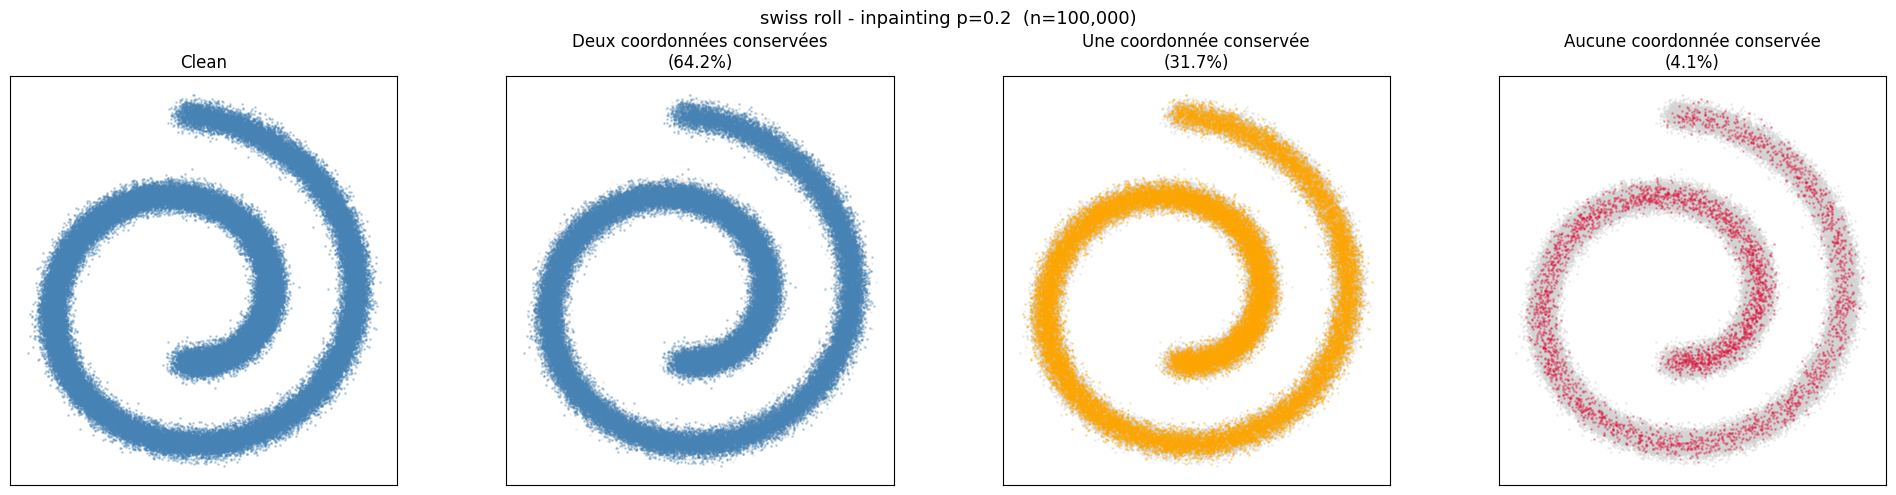

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
s = 1
alpha = 0.3

# 1 — Données clean
axes[0].scatter(X[:, 0], X[:, 1], s=s, alpha=alpha, c='steelblue')
axes[0].set_title("Clean")

# 2 — Deux coordonnées conservées
axes[1].scatter(X[~both, 0], X[~both, 1], s=s, alpha=alpha, c='lightgray')
axes[1].scatter(X[both, 0],  X[both, 1],  s=s, alpha=alpha, c='steelblue')
axes[1].set_title(f"Deux coordonnées conservées\n({100*both.mean():.1f}%)")

# 3 — Une seule coordonnée conservée
axes[2].scatter(X[~one, 0], X[~one, 1], s=s, alpha=alpha, c='lightgray')
axes[2].scatter(X[one, 0],  X[one, 1],  s=s, alpha=alpha, c='orange')
axes[2].set_title(f"Une coordonnée conservée\n({100*one.mean():.1f}%)")

# 4 — Aucune coordonnée conservée
axes[3].scatter(X[~none, 0], X[~none, 1], s=s, alpha=alpha, c='lightgray')
axes[3].scatter(X[none, 0],  X[none, 1],  s=s, alpha=alpha, c='crimson')
axes[3].set_title(f"Aucune coordonnée conservée\n({100*none.mean():.1f}%)")

for ax in axes:
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle(f"swiss roll - inpainting p=0.2  (n={n:,})", fontsize=13)
plt.tight_layout()
plt.savefig("swiss_roll_masks.png", dpi=150, bbox_inches='tight')
plt.show() 





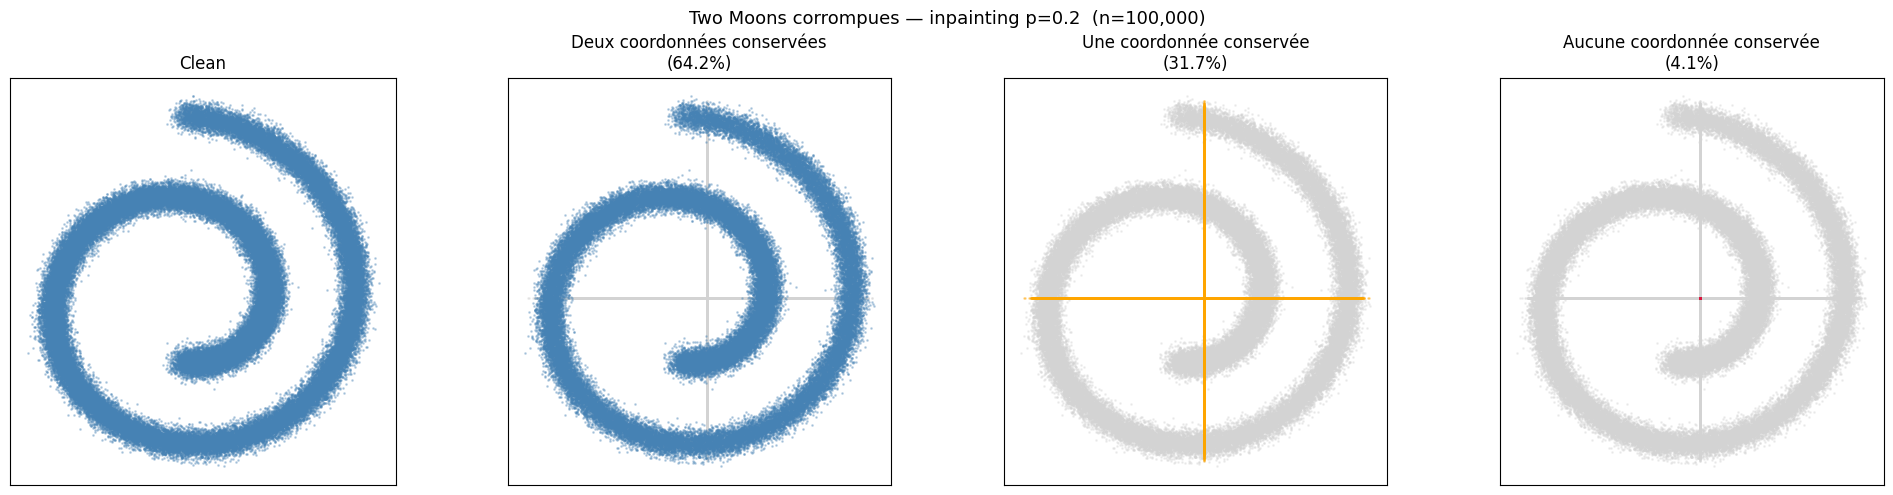

In [12]:
X_corrupted = X * A  # coordonnées masquées mises à 0

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
s = 1
alpha = 0.3

# 1 — Données clean
axes[0].scatter(X[:, 0], X[:, 1], s=s, alpha=alpha, c='steelblue')
axes[0].set_title("Clean")

# 2 — Deux coordonnées conservées (après corruption)
axes[1].scatter(X_corrupted[~both, 0], X_corrupted[~both, 1], s=s, alpha=alpha, c='lightgray')
axes[1].scatter(X_corrupted[both, 0],  X_corrupted[both, 1],  s=s, alpha=alpha, c='steelblue')
axes[1].set_title(f"Deux coordonnées conservées\n({100*both.mean():.1f}%)")

# 3 — Une seule coordonnée conservée (après corruption)
axes[2].scatter(X_corrupted[~one, 0], X_corrupted[~one, 1], s=s, alpha=alpha, c='lightgray')
axes[2].scatter(X_corrupted[one, 0],  X_corrupted[one, 1],  s=s, alpha=alpha, c='orange')
axes[2].set_title(f"Une coordonnée conservée\n({100*one.mean():.1f}%)")

# 4 — Aucune coordonnée conservée (après corruption)
axes[3].scatter(X_corrupted[~none, 0], X_corrupted[~none, 1], s=s, alpha=alpha, c='lightgray')
axes[3].scatter(X_corrupted[none, 0],  X_corrupted[none, 1],  s=s, alpha=alpha, c='crimson')
axes[3].set_title(f"Aucune coordonnée conservée\n({100*none.mean():.1f}%)")

for ax in axes:
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle(f"Two Moons corrompues — inpainting p=0.2  (n={n:,})", fontsize=13)
plt.tight_layout()
plt.savefig("two_moons_masks_corrupted.png", dpi=150, bbox_inches='tight')
plt.show()

## Training

In [ ]:
!python training/training.py --dataset generate_dataset/swiss_roll_p0.2.pkl \
    --schedule interpolation \
    --sigma_max 1.0 \
    --further_p 0.1 \
    --epochs 200 \
    --patience 20 \
    --batch_size 256 \
    --lr 1e-3 \
    --n_samples 10 \
    --n_steps 100 \
    --output .

# Launch benchmark experiments
## 1. Defining the configuration and saving it

In [ ]:
import json
import os

config = {
    "n_replicates": 5,
    "metrics": ["wd", "swd"],
    "output_folder": "./results",
    "datasets": {
        "type": "inpainting",
        "prevent_zero": 1,
        "p": [0.0, 0.2, 0.4, 0.6, 0.8],
        "delta": [0.0, 0.1, 0.3],
        "X_params": {
            "two_moons": {"n_sample": 5000, "noise": 0.1},
            "swiss_roll": {"n_sample": 5000, "noise": 0.4}
        }
    },
    "training_cfg": {
        "batch_size": 256,
        "schedule": "ve",
        "schedule_kwargs": {"sigma_min": 0.01, "sigma_max":1.0},
        "module_kwargs": {"data_dim":2, "hidden_dim":128, "n_layers":4, "time_embed_dim":32},
        "adam_kwargs": {"lr":1e-3},
        "sampler": "fms",
        "n_sample": 5000,
        "n_steps": 100
    },
    "viz": {
        "n_samples": 5000,
        "n_steps": 100
    }
}

os.makedirs(os.path.dirname('experiments/configs/inpainting_exp.json'), exist_ok=True)
with open('experiments/configs/inpainting_exp.json', 'w') as f:
    json.dump(config, f, indent=4)

## 2. Launching the experiments

In [ ]:
!python experiments/inpainting_experiment.py --cfg experiments/configs/inpainting_exp.json